    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     reason guardian  traveltime  studytime  failur

C:\Users\iLaptop.pk\AppData\Local\Temp\ipykernel_11036\3173030469.py:51: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace(binary_mapping)


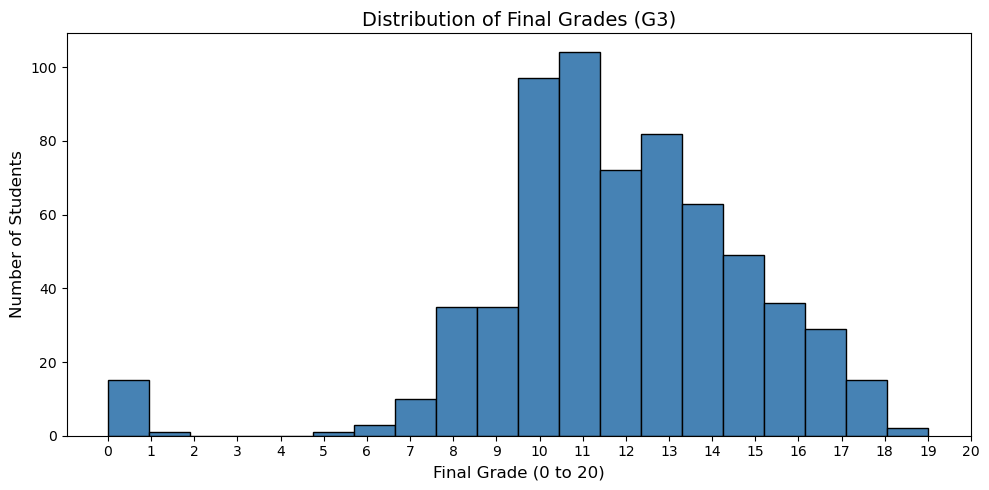

Pass rate at each study level:
studytime
1    76.415094
2    86.557377
3    92.783505
4    94.285714
Name: result, dtype: float64


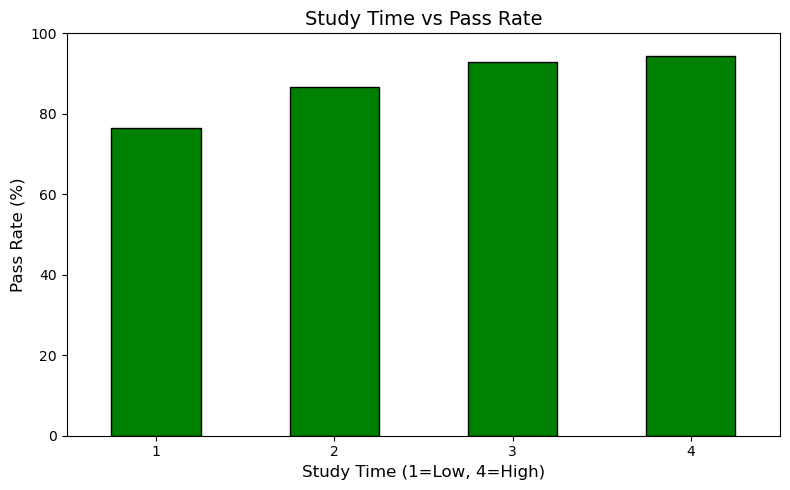

C:\Users\iLaptop.pk\AppData\Local\Temp\ipykernel_11036\3173030469.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='result', y='absences', data=absence_df, palette={'0': 'red', '1': 'green'})


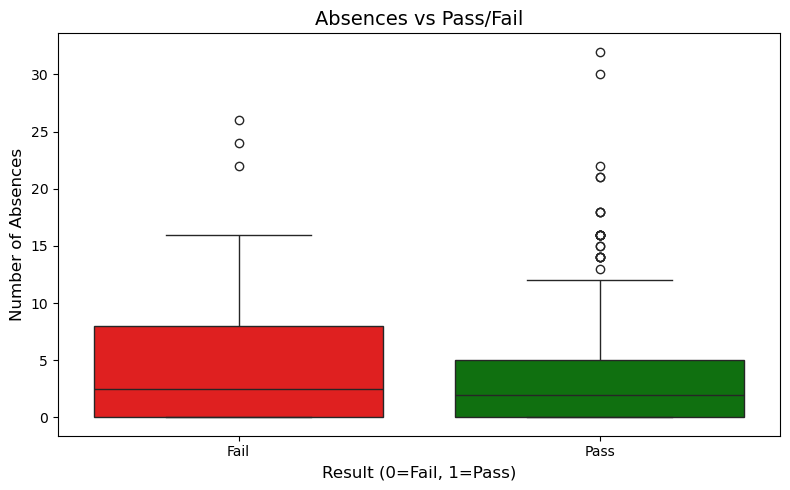

Average absences for failed students: 4.61
Average absences for passed students: 3.49


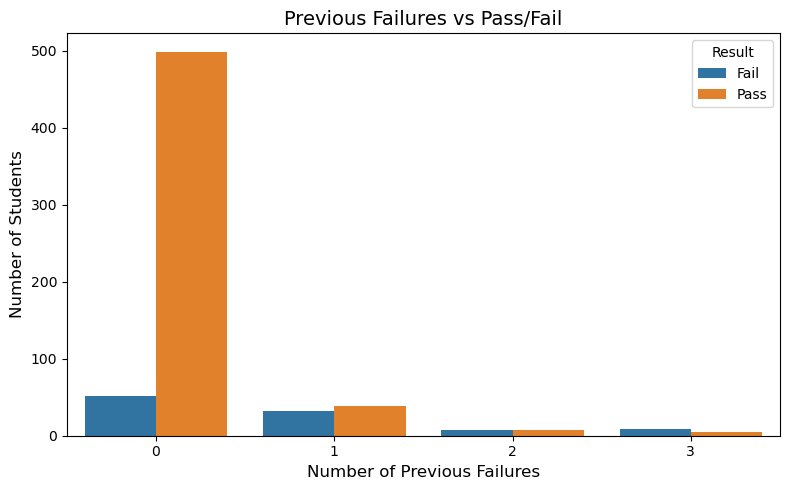

Pass rate at each failure level:
failures
0    90.71
1    54.29
2    50.00
3    35.71
Name: result, dtype: float64


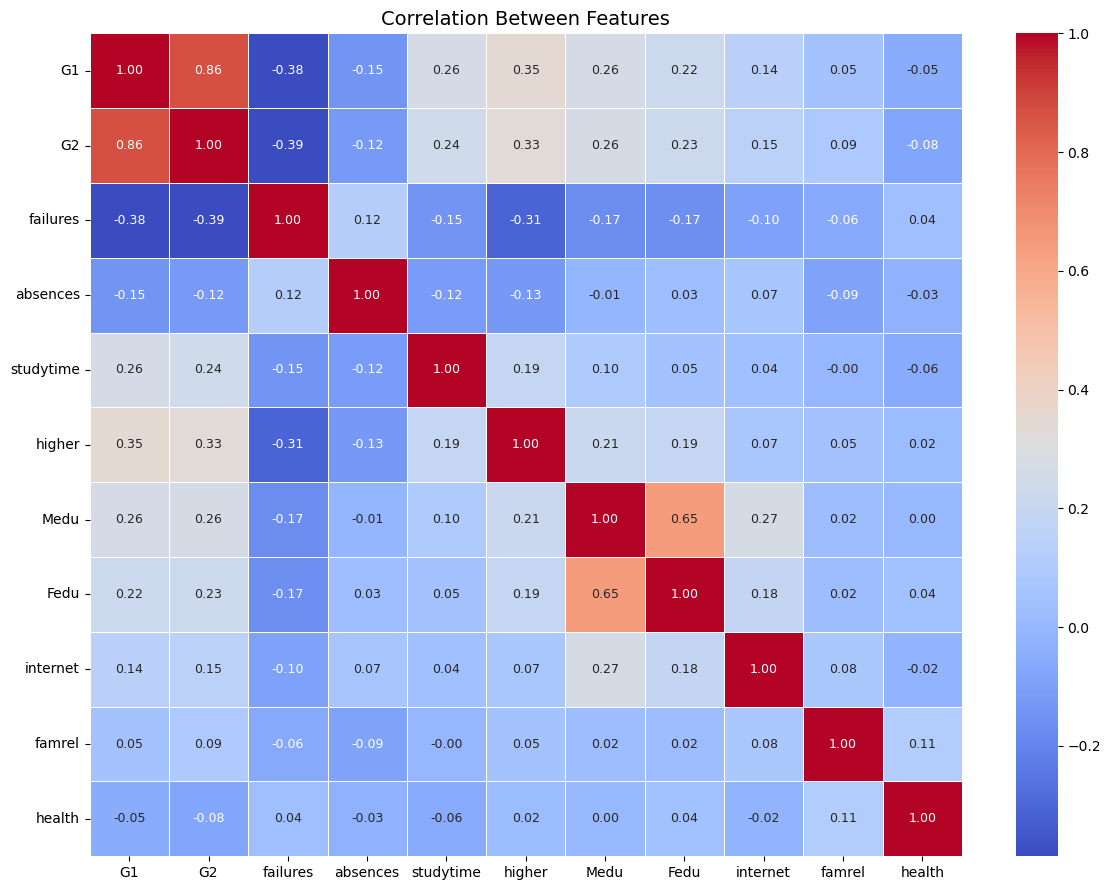

Training students: 519
Testing students: 130

Linear Regression Results
MAE  (Mean Absolute Error) : 0.73
MSE  (Mean Squared Error)  : 1.36
RMSE (Root Mean Sq Error)  : 1.17
Accuracy: 92.31%


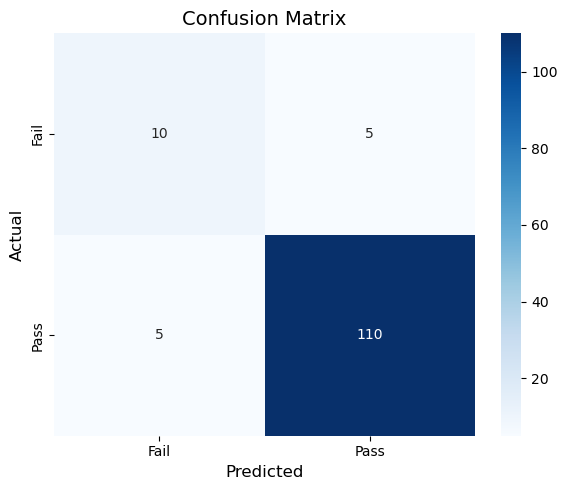


Classification Report:
              precision    recall  f1-score   support

        Fail       0.67      0.67      0.67        15
        Pass       0.96      0.96      0.96       115

    accuracy                           0.92       130
   macro avg       0.81      0.81      0.81       130
weighted avg       0.92      0.92      0.92       130

BAYESIAN PROBABILITY ANALYSIS

Study Time vs Passing
Pass with High Study Time = 93.18%
Pass with low Study Time  = 82.40%

Failure History vs Passing
Pass with 0 failures= 90.71% (549 students)
Pass with 1 failures= 54.29% (70 students)
Pass with 2 failures= 50.00% (16 students)
Pass with 3 failures= 35.71% (14 students)
MODEL EVALUATION(FEATURE SELECTION IMPACT)

Logistic Regression:
All features (41): 90.77%
Selected features (11): 92.31%

Linear Regression:
All features (41): MAE = 0.77
Selected features (11): MAE = 0.73

SUMMARY
Best Accuracy : 92.31%
Best MAE      : 0.73
Feature selection improved Logistic Regression accuracy from 90.7

Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs):  4
Previous Failures (0, 1, 2 or 3):  0
Number of Absences:  2
G1 - First Period Grade (0-20):  4
G2 - Second Period Grade (0-20):  15


PREDICTION RESULTS
  Predicted Grade     : 14.3 / 20
  Pass/Fail Status    : PASS
  Passing Probability : 98.3%

STUDENT RISK CLASSIFICATION REPORT
Risk Level
Low Risk       526
High Risk       90
Medium Risk     33
Name: count, dtype: int64

Top 10 High Risk Students:
|   Student ID |   G1 |   G2 |   failures |   absences |   studytime |   Pass Probability | Actual Result   | Risk Level   |
|-------------:|-----:|-----:|-----------:|-----------:|------------:|-------------------:|:----------------|:-------------|
|            1 |    0 |   11 |          0 |          4 |           2 |                3.4 | Pass            | High Risk    |
|           19 |    8 |    8 |          3 |          2 |           1 |               17   | Fail            | High Risk    |
|          151 |    9 |    8 |          0 |         24 |           2 |               48.2 | Fail            | High Risk    |
|          156 |    9 |    7 |          0 |         22 |           1 |               17   | Fail         

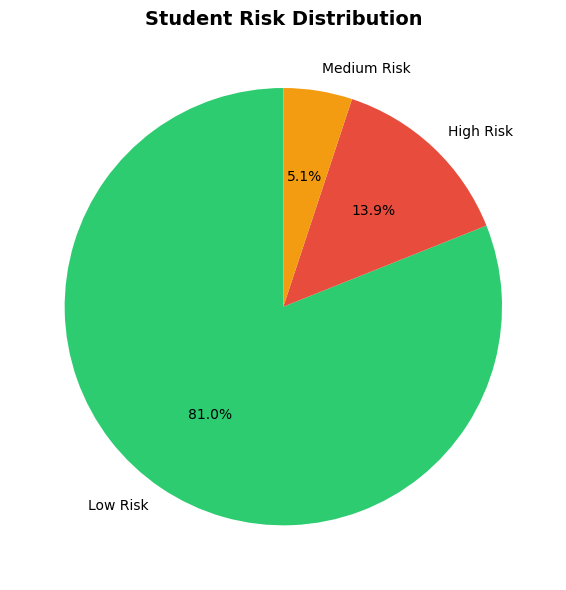

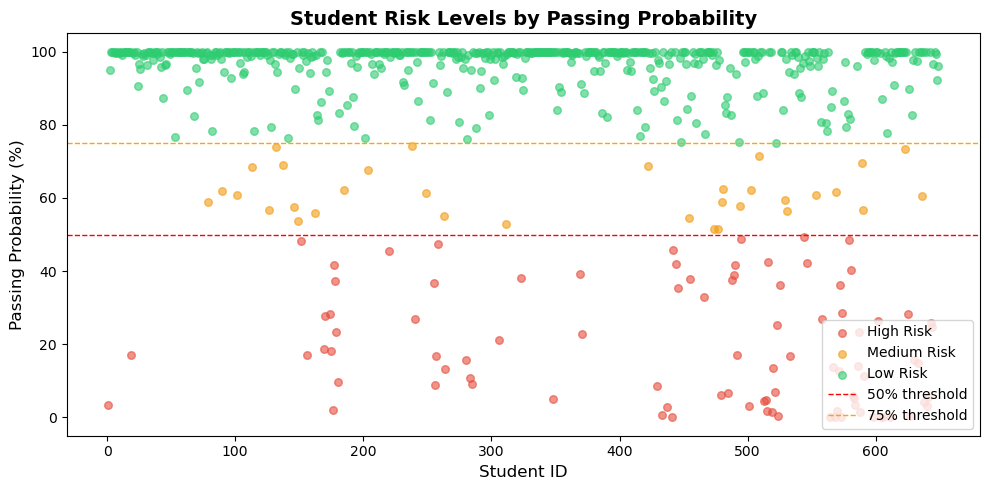

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\iLaptop.pk\Desktop\student-por.csv")
print(df)
print("\nShape of the Dataset (rows,columns):", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nNumber of Duplicate Rows:", df.duplicated().sum())
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical Columns:")
print(numerical_cols.tolist())
categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical Columns:")
print(categorical_cols.tolist())
print(f"\nTotal Numerical: {len(numerical_cols)}")
print(f"Total Categorical: {len(categorical_cols)}")



print("\nTotal missing values:", df.isnull().sum().sum(),"\n")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
binary_mapping = {
    'yes': 1,  'no': 0,
    'M': 1,    'F': 0,
    'U': 1,    'R': 0,
    'GT3': 1,  'LE3': 0,
    'T': 1,    'A': 0,
    'GP': 1,   'MS': 0
}
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']
df[binary_cols] = df[binary_cols].replace(binary_mapping)
print("\nAfter Label Encoding:")
print(df[binary_cols])
multi_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print("\nNew columns after One-Hot Encoding:")
print(df.columns.tolist())
print("New shape:", df.shape)
df['result'] = (df['G3'] >= 10).astype(int) #result added so total columns 43
print("\nPass/Fail Distribution:")
print(df['result'].value_counts())
df_clean = df.drop(columns=['G3'])
print("\nFinal Dataset Shape:", df_clean.shape)
print("\nFinal columns in our clean dataset:")
print(df_clean.columns.tolist())
print("\nFirst 3 rows:")
print(df_clean.head(3))
print("\nTarget variable unique values:", df_clean['result'].unique())
remaining_categorical = df_clean.select_dtypes(include='object').columns
print("\nRemaining text columns:", remaining_categorical.tolist(),"\n")



# kept on domain knowledge basis
final_features = [
    'G1', 'G2',       # Strongest predictors 
    'failures',        # Past failures
    'absences',        # Attendance 
    'studytime',       # Study hours
    'higher',          # Motivation 
    'Medu',            # Mother education 
    'Fedu',            # Father education 
    'internet',        # Resources 
    'famrel',          # Family environment 
    'health'           # Wellbeing 
]

print("Final Selected Features:")
print(final_features)
print("\nX shape:", X.shape)
print("\nFirst 5 rows of X:")
print(X.head())





#Task 1: Distribution of Final Grades (G3)
plt.figure(figsize=(10, 5))
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)', fontsize=14)
plt.xlabel('Final Grade (0 to 20)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(range(0, 21))
plt.tight_layout()
plt.show()

# Task 2: Study Time vs Performance
study_df = pd.DataFrame({'studytime': X['studytime'], 'result': y})
pass_rate = study_df.groupby('studytime')['result'].mean() * 100
print("Pass rate at each study level:")
print(pass_rate)               #1 = less than 2 hour, 2 = 2 to 5 hours, 3 = 5 to 10 hours, 4 = more than 10 hours
plt.figure(figsize=(8, 5))
pass_rate.plot(kind='bar', color='green', edgecolor='black')
plt.title('Study Time vs Pass Rate', fontsize=14)
plt.xlabel('Study Time (1=Low, 4=High)', fontsize=12)
plt.ylabel('Pass Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Task 3: Absences vs Result ---
absence_df = pd.DataFrame({'absences': X['absences'], 'result': y})
plt.figure(figsize=(8, 5))
sns.boxplot(x='result', y='absences', data=absence_df, palette={'0': 'red', '1': 'green'})
plt.title('Absences vs Pass/Fail', fontsize=14)
plt.xlabel('Result (0=Fail, 1=Pass)', fontsize=12)
plt.ylabel('Number of Absences', fontsize=12)
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.tight_layout()
plt.show()
print("Average absences for failed students:",round(absence_df[absence_df['result']==0]['absences'].mean(), 2))
print("Average absences for passed students:",round(absence_df[absence_df['result']==1]['absences'].mean(), 2))

# Task 4: Failures vs Result ---
failure_df = pd.DataFrame({'failures': X['failures'], 'result': y})
plt.figure(figsize=(8, 5))                                        # 0 = never failed before, 1 = failed once, 2 = failed twice, 3 = failed three times
sns.countplot(x='failures', hue='result', data=failure_df)
plt.title('Previous Failures vs Pass/Fail', fontsize=14)
plt.xlabel('Number of Previous Failures', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.legend(['Fail', 'Pass'], title='Result')
plt.tight_layout()
plt.show()
print("Pass rate at each failure level:")
print(round(failure_df.groupby('failures')['result'].mean() * 100, 2))

# Task 5: Correlation Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Between Features', fontsize=14)
plt.tight_layout()
plt.show()





y_regression = df['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y_regression, test_size=0.2, random_state=42)
print("Training students:", X_train.shape[0])
print("Testing students:", X_test.shape[0])
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("\nLinear Regression Results")
print(f"MAE  (Mean Absolute Error) : {mae:.2f}")
print(f"MSE  (Mean Squared Error)  : {mse:.2f}")
print(f"RMSE (Root Mean Sq Error)  : {rmse:.2f}")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_classification,test_size=0.2,random_state=42)
model_log = LogisticRegression(max_iter=2000)
model_log.fit(X_train, y_train)
y_pred = model_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues', xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred,target_names=['Fail','Pass']))


bayes_df = X.copy()
bayes_df['result'] = y.values
high_study = bayes_df[bayes_df['studytime'] >= 3]
p_pass_given_high_study = high_study['result'].mean() * 100
low_study = bayes_df[bayes_df['studytime'] <= 2]
p_pass_given_low_study = low_study['result'].mean() * 100
print("BAYESIAN PROBABILITY ANALYSIS")
print("\nStudy Time vs Passing")
print(f"Pass with High Study Time = {p_pass_given_high_study:.2f}%")
print(f"Pass with low Study Time  = {p_pass_given_low_study:.2f}%")

print("\nFailure History vs Passing")
for f in sorted(bayes_df['failures'].unique()):
    group = bayes_df[bayes_df['failures'] == f]
    prob = group['result'].mean() * 100
    total = len(group)
    print(f"Pass with {f} failures"f"= {prob:.2f}% "f"({total} students)")




    

# All features
X_all = df_clean.drop(columns=['result'])
y_class = df_clean['result']
y_reg = df['G3']
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_sel_scaled = scaler.fit_transform(X)

X_all_tr, X_all_te, y_tr, y_te = train_test_split(X_all_scaled, y_class, test_size=0.2, random_state=42)
X_sel_tr, X_sel_te, y_tr, y_te = train_test_split(X_sel_scaled, y_class, test_size=0.2, random_state=42)
log_all = LogisticRegression(max_iter=2000)
log_sel = LogisticRegression(max_iter=2000)
log_all.fit(X_all_tr, y_tr)
log_sel.fit(X_sel_tr, y_tr)
acc_all = accuracy_score(y_te, log_all.predict(X_all_te)) * 100
acc_sel = accuracy_score(y_te, log_sel.predict(X_sel_te)) * 100
print("MODEL EVALUATION(FEATURE SELECTION IMPACT)")
print(f"\nLogistic Regression:")
print(f"All features ({X_all.shape[1]}): {acc_all:.2f}%")
print(f"Selected features ({X.shape[1]}): {acc_sel:.2f}%")

X_all_tr2, X_all_te2, yr_tr, yr_te = train_test_split(X_all, y_reg, test_size=0.2, random_state=42)

X_sel_tr2, X_sel_te2, yr_tr, yr_te = train_test_split(X, y_reg, test_size=0.2, random_state=42)
lin_all = LinearRegression()
lin_sel = LinearRegression()
lin_all.fit(X_all_tr2, yr_tr)
lin_sel.fit(X_sel_tr2, yr_tr)
mae_all = mean_absolute_error(yr_te, lin_all.predict(X_all_te2))
mae_sel = mean_absolute_error(yr_te, lin_sel.predict(X_sel_te2))
print(f"\nLinear Regression:")
print(f"All features ({X_all.shape[1]}): MAE = {mae_all:.2f}")
print(f"Selected features ({X.shape[1]}): MAE = {mae_sel:.2f}")
print("\nSUMMARY")
print(f"Best Accuracy : {max(acc_all, acc_sel):.2f}%")
print(f"Best MAE      : {min(mae_all, mae_sel):.2f}")
print("Feature selection improved Logistic Regression accuracy from 90.77% to 92.31% and reduced Linear Regression MAE from 0.77 to 0.73, proving that removing irrelevant features improves model performance.")





print("  STUDENT PERFORMANCE PREDICTION SYSTEM")
print("\nEnter student details:")
studytime = int(input("Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs): "))
failures  = int(input("Previous Failures (0, 1, 2 or 3): "))
absences  = int(input("Number of Absences: "))
G1        = int(input("G1 - First Period Grade (0-20): "))
G2        = int(input("G2 - Second Period Grade (0-20): "))

higher   = round(X['higher'].mean())
Medu     = round(X['Medu'].mean())
Fedu     = round(X['Fedu'].mean())
famrel   = round(X['famrel'].mean())
health   = round(X['health'].mean())
internet = round(X['internet'].mean())           #because our model is trained on 11 features

user_input = pd.DataFrame([[G1, G2, failures, absences, studytime, higher, Medu, Fedu, famrel, health, internet]], columns=X.columns)
user_scaled = scaler.transform(user_input)

predicted_grade  = model_lr.predict(user_input)[0]
predicted_result = model_log.predict(user_scaled)[0]
pass_prob        = model_log.predict_proba(user_scaled)[0][1] * 100
status = "PASS" if predicted_result == 1 else "FAIL"

print("PREDICTION RESULTS")
print(f"  Predicted Grade     : {predicted_grade:.1f} / 20")
print(f"  Pass/Fail Status    : {status}")
print(f"  Passing Probability : {pass_prob:.1f}%")





#BONUS ADDITION
X_scaled_all = scaler.transform(X)
all_probs = model_log.predict_proba(X_scaled_all)[:, 1] * 100
risk_df = pd.DataFrame({
    'Student ID'         : range(1, 650),
    'G1'                 : X['G1'].values,
    'G2'                 : X['G2'].values,
    'failures'           : X['failures'].values,
    'absences'           : X['absences'].values,
    'studytime'          : X['studytime'].values,
    'Pass Probability'   : all_probs.round(1),
    'Actual Result'      : y.map({1: 'Pass', 0: 'Fail'}).values
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

def assign_risk(prob):
    if prob < 50:
        return 'High Risk'
    elif prob < 75:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['Risk Level'] = risk_df['Pass Probability'].apply(assign_risk)
print("\nSTUDENT RISK CLASSIFICATION REPORT")
print(risk_df['Risk Level'].value_counts())
high_risk = risk_df[risk_df['Risk Level'] == 'High Risk'].head(10)
print("\nTop 10 High Risk Students:")
print(high_risk.to_markdown(index=False))

risk_counts = risk_df['Risk Level'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(risk_counts.values,labels=risk_counts.index,colors=['#2ecc71', '#e74c3c', '#f39c12'],autopct='%1.1f%%',startangle=90)
plt.title('Student Risk Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

colors_map = {'High Risk'   : '#e74c3c', 'Medium Risk' : '#f39c12','Low Risk'    : '#2ecc71'}
for risk, color in colors_map.items():
    subset = risk_df[risk_df['Risk Level'] == risk]
    plt.scatter(subset['Student ID'],subset['Pass Probability'], c=color,  label=risk, alpha=0.6, s=30)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='50% threshold')
plt.axhline(y=75, color='orange', linestyle='--', linewidth=1, label='75% threshold')
plt.title('Student Risk Levels by Passing Probability', fontsize=14, fontweight='bold')
plt.xlabel('Student ID', fontsize=12)
plt.ylabel('Passing Probability (%)', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [101]:
import os
print("Your project is saved here:")
print(os.getcwd())

Your project is saved here:
C:\Users\iLaptop.pk
